# Quantum Volume Notebook

Quantum Volume (QV) is a single-number metric that can be measured using a concrete protocol on near-term quantum computers of modest size. The QV method quantifies the largest random circuit of equal width and depth that the computer successfully implements. Quantum computing systems with high-fidelity operations, high connectivity, large calibrated gate sets, and circuit rewriting toolchains are expected to have higher quantum volumes.

The Quantum Volume is determined by the largest successful circuit depth d_max, and equals to 2^{d_max}. A depth QV circuit is successful if it has mean heavy-output probability > 2/3 with confidence level > 0.977 (corresponding to z_value = 2), and at least 100 trials have been ran.

### Resources

- Quantum Volume: https://qiskit-community.github.io/qiskit-experiments/manuals/verification/quantum_volume.html
- Quantum Volume on the Qiskit Textbook: https://github.com/Qiskit/textbook/blob/main/notebooks/quantum-hardware/measuring-quantum-volume.ipynb





### Import modules

In [ ]:
from typing import Union, Sequence, Optional, List
import numpy as np
from numpy.random import Generator, default_rng
from numpy.random.bit_generator import BitGenerator, SeedSequence

from qiskit.quantum_info import Statevector
from qiskit import QuantumCircuit
from qiskit import qpy
from qiskit.circuit.library import quantum_volume
from qiskit import transpile
from qiskit.providers.backend import Backend
from qiskit_experiments.framework import BaseExperiment, Options

from collections import Counter
from qiskit_experiments.library.quantum_volume.qv_analysis import QuantumVolumeAnalysis

import matplotlib.pyplot as plt

### Define QV class

In [ ]:
class QuantumVolume(BaseExperiment):
    """An experiment to measure the largest random square circuit that can be run on a processor.

    # section: overview
        Quantum Volume (QV) is a single-number metric that can be measured using a concrete protocol
        on near-term quantum computers of modest size. The QV method quantifies the largest random
        circuit of equal width and depth that the computer successfully implements.
        Quantum computing systems with high-fidelity operations, high connectivity,
        large calibrated gate sets, and circuit rewriting toolchains are expected to
        have higher quantum volumes.

        The Quantum Volume is determined by the largest circuit depth :math:`d_{max}`,
        and equals to :math:`2^{d_{max}}`.
        See the `Qiskit Textbook
        <https://github.com/Qiskit/textbook/blob/main/notebooks/quantum-hardware/measuring-quantum-volume.ipynb>`_
        for an explanation on the QV protocol.

        In the QV experiment we generate :class:`~qiskit.circuit.library.QuantumVolume` circuits on
        :math:`d` qubits, which contain :math:`d` layers, where each layer consists of random 2-qubit
        unitary gates from :math:`SU(4)`, followed by a random permutation on the :math:`d` qubits.
        Then these circuits run on the quantum backend and on an ideal simulator (either
        :class:`~qiskit_aer.AerSimulator` or :class:`~qiskit.quantum_info.Statevector`).

        A depth :math:`d` QV circuit is successful if it has `mean heavy-output probability` > 2/3 with
        confidence level > 0.977 (corresponding to z_value = 2), and at least 100 trials have been ran.

        See :class:`QuantumVolumeAnalysis` documentation for additional
        information on QV experiment analysis.

    # section: analysis_ref
        :class:`QuantumVolumeAnalysis`

    # section: manual
        :doc:`/manuals/verification/quantum_volume`

    # section: reference
        .. ref_arxiv:: 1 1811.12926
        .. ref_arxiv:: 2 2008.08571

    # section: example
        .. jupyter-execute::
            :hide-code:

            # backend
            from qiskit_aer import AerSimulator
            from qiskit_ibm_runtime.fake_provider import FakeSydneyV2
            backend = AerSimulator.from_backend(FakeSydneyV2())

        .. jupyter-execute::

            from qiskit_experiments.framework import BatchExperiment
            from qiskit_experiments.library import QuantumVolume

            qubits = tuple(range(4)) # Can use specific qubits. for example [2, 4, 7, 10]
            qv_exp = QuantumVolume(qubits, seed=42)
            qv_exp.set_transpile_options(optimization_level=3)
            qv_exp.set_run_options(shots=1000)

            expdata = qv_exp.run(backend=backend).block_for_results()
            display(expdata.figure(0))

            display(expdata.analysis_results(dataframe=True))
    """

    def __init__(
        self,
        physical_qubits: Sequence[int],
        backend: Optional[Backend] = None,
        trials: Optional[int] = 100,
        seed: Optional[Union[int, SeedSequence, BitGenerator, Generator]] = None,
        simulation_backend: Optional[Backend] = None,
        bootstrap: bool = False,
    ):
        """Initialize a quantum volume experiment.

        Args:
            physical_qubits: list of physical qubits for the experiment.
            backend: Optional, the backend to run the experiment on.
            trials: The number of trials to run the quantum volume circuit.
            seed: Optional, seed used to initialize ``numpy.random.default_rng``
                  when generating circuits. The ``default_rng`` will be initialized
                  with this seed value every time :meth:`circuits` is called.
            simulation_backend: The simulator backend to use to generate
                the expected results. the simulator must have a 'save_probabilities'
                method. If None, the :class:`qiskit_aer.AerSimulator` simulator will be used
                (in case :external+qiskit_aer:doc:`qiskit-aer <index>` is not
                installed, :class:`qiskit.quantum_info.Statevector` will be used).
        """
        analysis=QuantumVolumeAnalysis()
        analysis.set_options(bootstrap=bootstrap)
        super().__init__(physical_qubits, analysis=analysis, backend=backend)

        # Set configurable options
        self.set_experiment_options(trials=trials, seed=seed)

        self.heavy_strings = [] # list of heavy strings per circuit
        self.heavy_outputs_ideal = [] # ideal: list of heavy output probabilities for each ciruit
        self.heavy_outputs_data = [] # experimental: list of heavy output probabilities for each ciruit
        self.circuits_to_simulate = [] # list of circuits to simulate 
        self.experimental_results = [] # experimental results from sampler
        self.analysis_results = None # analysis results from experimental data
        self.shots = [] # number of shots for each circuit

    @classmethod
    def _default_experiment_options(cls) -> Options:
        """Default experiment options.

        Experiment Options:
            trials (int): Optional, number of times to generate new Quantum Volume
                circuits and calculate their heavy output.
            seed (None or int or SeedSequence or BitGenerator or Generator): A seed
                used to initialize ``numpy.random.default_rng`` when generating circuits.
                The ``default_rng`` will be initialized with this seed value every time
                :meth:`circuits` is called.
        """
        options = super()._default_experiment_options()

        options.trials = 100
        options.seed = None

        return options

    def _get_ideal_data(self, circuits: List[QuantumCircuit], **run_options) -> List[List[float]]:
        """Return ideal measurement probabilities.

        In case the user does not have Aer installed, use Qiskit's quantum info module
        to calculate the ideal state.

        Args:
            circuits: the circuits to extract the ideal data from
            run_options: backend run options.

        Returns:
            list: list of lists of the probabilities for each state in each circuit.
        """
        if not circuits:
            # retrieve generated circuits (this retrieves custom circuits if previously uploaded)
            if self.circuits_to_simulate:
                circuits = self.circuits_to_simulate
            # generate circuits if not previosuly done
            else:
                circuits = self.circuits()
        probabilities = []
        all_heavy_strings = []
        for c in circuits:
            zero = Statevector.from_label('0' * c.num_qubits)
            sv = zero.evolve(c)
            probs = sv.probabilities().tolist()
            ideal_data = sv.probabilities_dict()
            prob_median = float(np.real(np.median(probs)))
            heavy_strings = list(
                filter(
                    lambda x: ideal_data[x] > prob_median,
                    list(ideal_data.keys()),
                )
            )
            probabilities.append(probs)
            all_heavy_strings.append(heavy_strings)

        self.heavy_outputs_ideal = probabilities
        self.heavy_strings = all_heavy_strings
        return probabilities

    def circuits(self, filepath=None) -> List[QuantumCircuit]:
        """Return a list of Quantum Volume circuits.

        Returns:
            A list of :class:`QuantumCircuit`.
        """
        if filepath is None:
            rng = default_rng(seed=self.experiment_options.seed)
            circuits = []
            depth = self._num_qubits
    
            # Note: the trials numbering in the metadata is starting from 1 for each new experiment run
            for trial in range(1, self.experiment_options.trials + 1):
                # Maximum possible seed to send to quantum_volume()
                # This is a workound that can be replaced with seed=rng once we
                # drop support for qiskit<2.2
                # See https://github.com/Qiskit/qiskit/pull/14586
                max_value = np.iinfo(np.int64).max
                qv_circ = quantum_volume(depth, depth, seed=rng.integers(max_value, dtype=np.int64))
                qv_circ.metadata = {
                    "depth": depth,
                    "trial": trial,
                }
                circuits.append(qv_circ)
            all_probs = self._get_ideal_data(circuits)
            for qv_circ, probs in zip(circuits, all_probs):
                qv_circ.measure_active()
                qv_circ.metadata["ideal_probabilities"] = probs
            self.circuits_to_simulate = circuits
        else:
            try:
                # load custom circuits
                with open(filepath, 'rb') as f:
                    circuits = qpy.load(f)
            except FileNotFoundError:
                print(f"Error: The specified filepath was not found: {filepath}")
            circuits = circuits[0:self.experiment_options.trials]
            self.cicuits_to_simulate = circuits
        return circuits

    def _populate_heavy_ouputs(self, results, ideal_data):
        shots_list = []
        heavy_outputs = []
        for i, result in enumerate(results):
            cname = list(result.data.keys())[0]
            bitstrings_list = result.data[cname].get_bitstrings() # all measured bitstrings
            counts = Counter(bitstrings_list) # bitstring counts
            shots = sum(counts.values())
            # heavy_outputs_ideal = ideal_data[i]
            # prob_median = float(np.real(np.median(list(heavy_outputs_ideal.values()))))
            # heavy_strings = list(
            #     filter(
            #         lambda x: heavy_outputs_ideal[x] > prob_median,
            #         list(heavy_outputs_ideal.keys()),
            #     )
            # )
            heavy_strings = self.heavy_strings[i]
            heavy_output_probability = sum([counts.get(value, 0) for value in heavy_strings]) / shots
            heavy_outputs.append(heavy_output_probability)
            shots_list.append(shots)
        self.heavy_outputs_data = heavy_outputs
        self.shots = shots_list
        return self.heavy_outputs_data

    def add_experimental_results(self,results):
        self.experimental_results = results

    def analyze_results(self, use_bootstrapping=False, resampling=1000):
        from scipy.special import erf
        
        heavy_outputs_data = None
        if self.experimental_results and self.heavy_outputs_ideal:
            heavy_outputs_data = self._populate_heavy_ouputs(self.experimental_results, self.heavy_outputs_ideal)
        elif len(self.heavy_outputs_ideal) == 0:
            print('Ideal results have not been simulated yet. Please run ._get_ideal_data(circuits) first.')
        else:
            print('Experiment results have not been added yet. Please run .add_experimental_results(results) first.')

        mean_hop = np.asarray(heavy_outputs_data).mean()
        hop_accumulative = np.cumsum(heavy_outputs_data) / np.arange(1, len(heavy_outputs_data) + 1)
        trials = self.experiment_options.trials
        depth = self.num_qubits
        shots_list = self.shots
        quantum_volume = 1
        success = False
        quality = 'bad'

        if use_bootstrapping is True:
            # resample data 
            # Confidence intervals
            lower_ci = []
            upper_ci = []
            
            # Quantiles for 97.7% confidence interval (using erf)
            q_lo = 1/2 + erf(np.sqrt(2))/2   # ≈ 0.9772
            q_hi = 1/2 - erf(np.sqrt(2))/2   # ≈ 0.0228
            
            for i in range(1, trials + 1):
                # resample data
                resampled_ind = np.random.randint(0, i, size=(resampling, i))
                shot_list = np.array(shots_list[:i])
                resampled_shots = shot_list[resampled_ind]
                success_list = np.array(heavy_outputs_data[:i])*shot_list
                
                resampled_shots = shot_list[resampled_ind]
                resampled_probs = success_list[resampled_ind]/resampled_shots
                
                resampled_success = (
                    np.sum(np.random.binomial(shot_list[resampled_ind], resampled_probs), axis=1)
                    / np.sum(resampled_shots, axis=1)
                    )

                # Compute percentile-based CI using reflection method
                qv_mean = np.asarray(heavy_outputs_data[:i]).mean()
                lower = 2 * qv_mean - np.quantile(resampled_success, q_lo)
                upper = 2 * qv_mean - np.quantile(resampled_success, q_hi)
                
                lower_ci.append(lower)
                upper_ci.append(upper)
                
            lower_ci = np.array(lower_ci)
            upper_ci = np.array(upper_ci) 
            threshold = 2/3
            if lower_ci[-1] > threshold and trials >= 100:
                quantum_volume = 2**depth
                success = True
                quality = 'good'
    
            hop_result = {
                'mean_hop':mean_hop,
                "lower_ci": lower_ci[-1],
                "upper_ci": upper_ci[-1],
                'quantum_volume': quantum_volume,
                'quality': quality,
                "success": success,
                "HOPs": [heavy_outputs_data],
                "hop_accumulative": [hop_accumulative],
                "upper_cis": [upper_ci],
                "lower_cis": [lower_ci],
                "depth": depth,
                "trials": trials,
                'bootstrapping': True,
            }
        else:
            mean_hop = np.asarray(heavy_outputs_data).mean()
            sigma_hop = (mean_hop * ((1.0 - mean_hop) / trials)) ** 0.5
            z = 2
            z_value = (mean_hop - 2 / 3) / sigma_hop
            confidence_level = 0.5 * (1 + erf(z_value / 2**0.5))
            if confidence_level > 0.977:
                quality = "good"

            threshold = 2 / 3 + z * sigma_hop
            if mean_hop > threshold and trials >= 100:
                quantum_volume = 2**depth
                success = True

            hop_result = {
                'mean_hop':mean_hop,
                "two_sigma": 2*sigma_hop,
                'quantum_volume': quantum_volume,
                'quality': quality,
                "success": success,
                "HOPs": [heavy_outputs_data],
                "hop_accumulative": [hop_accumulative],
                "confidence": confidence_level,
                "depth": depth,
                "trials": trials,
                'bootstrapping': False,
            }
        import pandas as pd
        self.analysis_results = pd.DataFrame(hop_result) 
        return self.analysis_results


    def plot_hop_accumulative(self):
        if self.analysis_results is None:
            print('The method .analyze_results() has not been run yet, please run .analyze_results() before attempting to plot the results')
        else:
            depth = self.analysis_results['depth'][0]
            hops = self.analysis_results['HOPs'][0]
            hop_accumulative = self.analysis_results['hop_accumulative'][0]
            trials = list(range(1, len(hop_accumulative)+1))
            if self.analysis_results['bootstrapping'][0]:
                upper = self.analysis_results['upper_cis'][0]
                lower = self.analysis_results['lower_cis'][0]
                label = 'Bootstrap CI Bound'
                ylim = [max(0, 0.95*lower[0]), min(1, max(1.1*upper[0],0.7))]
            else:
                hop_twosigma = 2 * (hop_accumulative * (1 - hop_accumulative) / trials) ** 0.5
                upper = hop_accumulative + hop_twosigma
                lower = hop_accumulative - hop_twosigma
                label = '2 sigma'
                ylim = [max(0, 0.75*np.mean(lower)), min(1, max(1.25*np.mean(upper),0.7))]
    
        fig, ax = plt.subplots(1, 1, figsize=(7,5))
        ax.scatter(trials, hops, s=4, zorder=4, label='Individual Heavy-output Probability', alpha=0.5)
        ax.plot(trials, hop_accumulative, color='r', label='Cumulative Heavy-output Probability')
        ax.plot(trials, lower, '-g', alpha=1, label=label)
        ax.plot(trials, upper, '-g', alpha=1)
        ax.fill_between(
                    trials,
                    y1=upper,
                    y2=lower,
                    alpha=0.3,
                    color='g'
                )
    
        # plot 2/3 success threshold
        ax.axhline(2/3, color='k', linestyle='dashed', linewidth=1, label='Passing Threshold')
        ax.set_xlim(0, len(hops))
        ax.set_ylim(ylim)
        ax.set_xlabel('Number of Trials', fontsize=14)
        ax.set_ylabel('Heavy Output Probability', fontsize=14)
    
        # re-arrange legend order
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles, labels)
        ax.set_title(
            f'Quantum Volume experiment for depth {depth} (mean hop: {hop_accumulative[-1]:.4f})'
        )
        

### Setup backend

In [115]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()
backend = service.backend('ibm_kingston')

## Step 1: Map classical inputs to a quantum problem

#### Create QV instances

In [ ]:
# create QV instance
qubit_list = list(range(0,10)) # size and depth of the QV circuit
trials = 200
qv = QuantumVolume(physical_qubits=qubit_list, backend=backend, trials=trials)

In [ ]:
# load circuits from filepath
circuits_orig = qv.circuits(filepath = './qv_circuits/qv1024_original.qpy') # original circuits
circuits_opt = qv.circuits(filepath = './qv_circuits/qv1024_ring.qpy') # circuits optimized for a ring

In [173]:
# this should match the number of trials
len(circuits_orig), len(circuits_opt), trials

(200, 200, 200)

#### Transpile optimized circuits

In [119]:
# Assuming circuits are optimized for a line

# print('Pre-transpiling circuits optimized for a line')
    
# # this takes the AI pre-transpiled circuits as is
# bare = transpile(circuits_opt,
#                       backend=backend,
#                 approximation_degree=1,
#                 optimization_level=1)

# # this takes the AI pre-transpiled circuits as is
# bare_ol3 = transpile(circuits_opt,
#                       backend=backend,
#                 approximation_degree=1,
#                 optimization_level=3)

In [120]:
# Assuming circuits are optimized for a ring of size 12Q

print('Transpiling circuits optimized for a ring')

# this takes the AI pre-transpiled circuits as is. we don't apply any layout/routing heuristics and which makes this process fast
bare = transpile(circuits_opt,
                coupling_map =[[0,1],[1,2],[2,3],[3,4],[4,5],[5,6],[6,7],[7,8],[8,9],[9,10],[10,11],[11,0],
                              [1,0],[2,1],[3,2],[4,3],[5,4],[6,5],[7,6],[8,7],[9,8],[10,9],[11,10],[0,11]],
                basis_gates = backend.configuration().basis_gates,
                approximation_degree=1,
                optimization_level=1)

# if we apply opt level 3, we can get another little boost in reducing number of gates we run the saber heuristics. While the AI pre-transpile is better than anything qiskit can do, doing the saber on top can give a small improvement
bare_ol3 = transpile(circuits_opt,
                coupling_map =[[0,1],[1,2],[2,3],[3,4],[4,5],[5,6],[6,7],[7,8],[8,9],[9,10],[10,11],[11,0],
                              [1,0],[2,1],[3,2],[4,3],[5,4],[6,5],[7,6],[8,7],[9,8],[10,9],[11,10],[0,11]],
                basis_gates = backend.configuration().basis_gates,
                approximation_degree=1,
                optimization_level=3)

Transpiling circuits optimized for a ring


In [ ]:
import mapomatic as mm

# Now that we have multiple transpilations of the same circuit, we just pick the best option for each circuit
best_of_all = []
for i in range(trials):
    if bare[i].count_ops()['cz'] <= bare_ol3[i].count_ops()['cz']:
        best_of_all.append(bare[i])
    else:
        best_of_all.append(bare_ol3[i])

# find largest circuit, we will use this one to find the best layout
czs = 1
for circ in best_of_all:
    if circ.count_ops()['cz'] > czs:
        largest_circuit = circ
        czs = circ.count_ops()['cz']

# sanity check: make sure all uploaded circuits have the same number of active qubits
size = None
for circ in best_of_all:
    dfcirc = mm.deflate_circuit(circ)
    if size is None:
        size = dfcirc.num_qubits
    if dfcirc.num_qubits != size:
        best_of_all.remove(circ)

## Step 2: Optimize problem for quantum hardware execution

#### Find the best layout

First, we find all possible layout configrations for a line or ring on the device. Then, we evaluate each of these configurtaions according to some cost function (which takes into account SPAM and control errors) to find the best layout.

In [122]:
# reduce the size of the largest transpiled circuit down to only active qubits
deflated_circuit = mm.deflate_circuit(largest_circuit)

# find all possible layouts for the deflated circuit
all_possible_layouts = mm.matching_layouts(deflated_circuit, backend)

# evaluate all possible layout to find the best one
best_layout = mm.evaluate_layouts(deflated_circuit, all_possible_layouts, backend)[0][0]

In [123]:
print('Best layout:', best_layout)

Best layout: [97, 107, 108, 109, 110, 111, 98, 91, 90, 89, 88, 87]


#### Transpile circuits on the best layout

In [ ]:
from qiskit.circuit.library import XGate, RZGate
from qiskit.transpiler.passes import ALAPScheduleAnalysis, PadDynamicalDecoupling
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.transpiler import PassManager

### set scheduling and DD PM
dd_sequence=[XGate(), RZGate(np.pi), XGate(), RZGate(-np.pi)]
spacing = [1 / 4, 1 / 2, 0, 0, 1 / 4]

scheduling_pm = PassManager(
    [
        ALAPScheduleAnalysis(target=backend.target),
        PadDynamicalDecoupling(target=backend.target, dd_sequence=dd_sequence, spacing=spacing)
    ]
)

pm      = generate_preset_pass_manager( 0,
                                        backend,
                                        initial_layout = best_layout,
                                        approximation_degree=1,
                                        seed_transpiler=1
                                        )
pm.scheduling = scheduling_pm

transpiled_circuits = []
for circ in best_of_all:
    dfcirc = mm.deflate_circuit(circ)
    transpiled_circuits.append(pm.run(dfcirc))


In [183]:
len(transpiled_circuits)

200

## Step 3: Execute using Qiskit primitives

#### Run QV circuits

In [39]:
from qiskit_ibm_runtime import SamplerV2 as Sampler

shots = 1000
sampler = Sampler(backend)
job = sampler.run(transpiled_circuits, shots=shots)

print(job.job_id())

d2cvkogf4s4s73dfrvcg


In [50]:
# Retrieve job from job_id
job = service.job('d2cvkogf4s4s73dfrvcg')
exp_result = job.result()

## Step 4.2: Post-process and return results in desired classical format

In [174]:
# Retrieve experimental results from sampler
results = job.result()

In [ ]:
# Add sampler results to QV instance for analysis
qv.add_experimental_results(results=results)

In [ ]:
# Simulate ideal heavy output probabilities from the circuits we loaded earlier  
ideal_results = qv._get_ideal_data(circuits=circuits_orig)

In [185]:
# Analyze sampler results using bootstrapping
qv_result_bootstrapping = qv.analyze_results(use_bootstrapping=True)

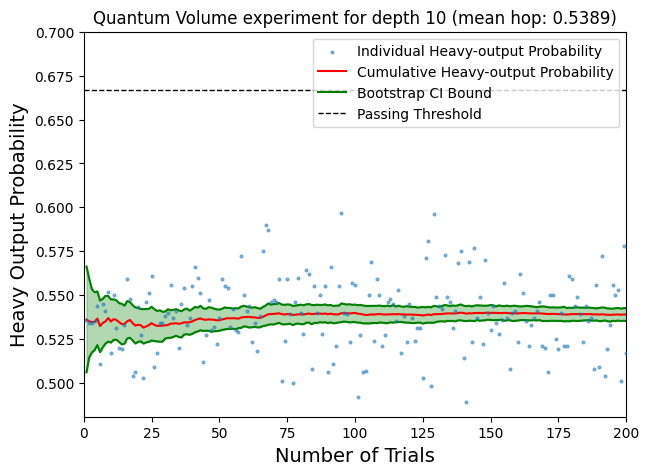

In [186]:
qv.plot_hop_accumulative()

In [179]:
qv_result_bootstrapping

,mean_hop,lower_ci,upper_ci,quantum_volume,quality,success,HOPs,hop_accumulative,upper_cis,lower_cis,depth,trials,bootstrapping
0,0.538855,0.535333,0.5425,1,bad,False,"[0.536, 0.534, 0.534, 0.535, 0.544, 0.511, 0.5...","[0.536, 0.535, 0.5346666666666667, 0.534750000...","[0.5672726181837691, 0.5565000000000001, 0.552...","[0.5040000000000001, 0.5135000000000001, 0.517...",10,200,True


In [180]:
# Analyze sampler results without bootstrapping
qv_result = qv.analyze_results(use_bootstrapping=False)

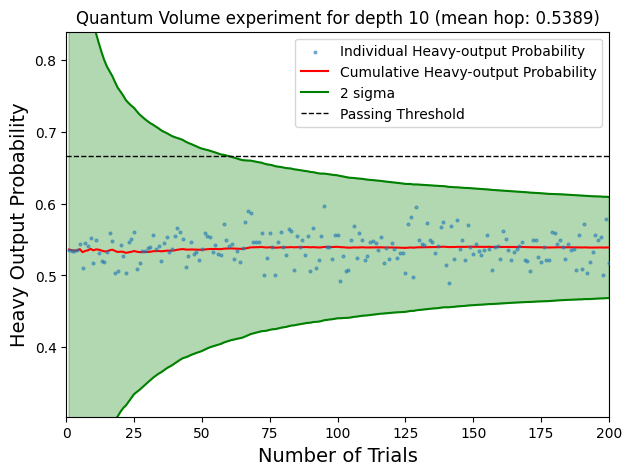

In [181]:
qv.plot_hop_accumulative()

In [182]:
qv_result

,mean_hop,two_sigma,quantum_volume,quality,success,HOPs,hop_accumulative,confidence,depth,trials,bootstrapping
0,0.538855,0.070497,1,bad,False,"[0.536, 0.534, 0.534, 0.535, 0.544, 0.511, 0.5...","[0.536, 0.535, 0.5346666666666667, 0.534750000...",0.000144,10,200,False
